In [1]:
import numpy as np 
import seaborn as sns
import pandas as pd
import matplotlib as plt

In [2]:
df = pd.read_csv("C:/Users/HARSHITHA/Desktop/ban_house/bangalore_house_price_prediction/Bengaluru_House_Data.csv")

In [3]:
df.head(2)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00


In [4]:
# drop unwanted cloumns 
col = ["area_type", "availability", "society", "balcony"]
df = df.drop(col, axis = 1)
df

,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Richards Town,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00
13318,Padmanabhanagar,4 BHK,4689,4.0,488.00


In [5]:
df.isnull().sum()


location       1
size          16
total_sqft     0
bath          73
price          0
dtype: int64

In [6]:
# drop duplicate rows 
df.drop_duplicates(inplace=True)

In [7]:
# cleaning in location
# removing whitespaces 
df["location"]  = df["location"].str.strip()
# handling null values 
df["location"] = df["location"].fillna("Sarjapur  Road")
# grrouping the locations with less than 10 
loc = df["location"].value_counts()
loc_less = loc[loc<=10]
df["location"] = df["location"].apply(lambda x: "others" if x in loc_less else x)
df


,location,size,total_sqft,bath,price
0,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...
13314,Green Glen Layout,3 BHK,1715,3.0,112.00
13315,Whitefield,5 Bedroom,3453,4.0,231.00
13316,others,4 BHK,3600,5.0,400.00
13317,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00


In [8]:
df.isnull().sum()


location       0
size          16
total_sqft     0
bath          72
price          0
dtype: int64

In [9]:
# cleaning size column
# Handling null values 
df["size"] = df["size"].fillna("2 BHK")
# extract only bhk value, remove unwanted chars and convert it into integer 
df["size"] =  df["size"].apply(lambda x: int(x.split()[0]))
# renaming size to bhk for proper readability 
df.rename(columns={"size":"BHK"}, inplace = True )
df["BHK"].unique()


array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [10]:
df.isnull().sum()


location       0
BHK            0
total_sqft     0
bath          72
price          0
dtype: int64

In [11]:
# clean total_sqft column
# 
def tot_sqft(sqft):
    try: 
        l = sqft.split("-")
        if len(l)==2:
            return (float(l[0])+ float(l[1]))/2
        else:
            return float(l[0])
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(tot_sqft)
# handling null values 
df['total_sqft'] = df['total_sqft'].fillna(round(df['total_sqft'].mean()))


In [12]:
df.isnull().sum()


location       0
BHK            0
total_sqft     0
bath          72
price          0
dtype: int64

In [13]:
# cleaning bath column
# Handling null values
df['bath'] = df['bath'].fillna(df['bath'].median())
df

,location,BHK,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
13314,Green Glen Layout,3,1715.0,3.0,112.00
13315,Whitefield,5,3453.0,4.0,231.00
13316,others,4,3600.0,5.0,400.00
13317,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00


In [14]:
df['bath'].unique()

array([ 2.,  5.,  3.,  4.,  6.,  1.,  9.,  8.,  7., 11., 10., 14., 27.,
       12., 16., 40., 15., 13., 18.])

In [15]:
df.isnull().sum()


location      0
BHK           0
total_sqft    0
bath          0
price         0
dtype: int64

## Handling Outliers 

In [16]:
# create a new column price_per_sqft
# formula = price_per_sqft = price = total_sqft
df['price_per_sqft'] = df['price'] / df['total_sqft']
df

,location,BHK,total_sqft,bath,price,price_per_sqft
0,Electronic City Phase II,2,1056.0,2.0,39.07,0.036998
1,Chikka Tirupathi,4,2600.0,5.0,120.00,0.046154
2,Uttarahalli,3,1440.0,2.0,62.00,0.043056
3,Lingadheeranahalli,3,1521.0,3.0,95.00,0.062459
4,Kothanur,2,1200.0,2.0,51.00,0.042500
...,...,...,...,...,...,...
13314,Green Glen Layout,3,1715.0,3.0,112.00,0.065306
13315,Whitefield,5,3453.0,4.0,231.00,0.066898
13316,others,4,3600.0,5.0,400.00,0.111111
13317,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,0.052585


In [17]:
# handling outliers in total_sqft
# observation: In total_sqft we have less than 300 sqft which are outliers 
# In real_time we can see that all rge houses starts from 300 sqft minimum
# formula = total_sqft / bhk >= 300  --> it keeps all the realistic 

df = df[df['total_sqft']/df['BHK'] >= 300]
df['total_sqft'].value_counts()

total_sqft
1200.0    602
1100.0    195
2400.0    191
1500.0    187
1000.0    143
         ... 
4225.0      1
3734.0      1
964.0       1
4007.0      1
7150.0      1
Name: count, Length: 1961, dtype: int64

In [18]:
# Hnadling outlier for BHK
df = df[df['BHK']<=6]
# sns.boxplot(x = 'BHK', data = df)
df

,location,BHK,total_sqft,bath,price,price_per_sqft
0,Electronic City Phase II,2,1056.0,2.0,39.07,0.036998
1,Chikka Tirupathi,4,2600.0,5.0,120.00,0.046154
2,Uttarahalli,3,1440.0,2.0,62.00,0.043056
3,Lingadheeranahalli,3,1521.0,3.0,95.00,0.062459
4,Kothanur,2,1200.0,2.0,51.00,0.042500
...,...,...,...,...,...,...
13314,Green Glen Layout,3,1715.0,3.0,112.00,0.065306
13315,Whitefield,5,3453.0,4.0,231.00,0.066898
13316,others,4,3600.0,5.0,400.00,0.111111
13317,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,0.052585


In [19]:
# Handling outlier in bath column
df[df['bath']>df['BHK']+2][['BHK','bath']]
# Obesrvation: Here there are count of bath where it is suspeciously high compared to bhk these are outliers 
df = df[df['bath']<df['BHK']+2]  # it removes un realistic values where the count of bath values suspeciously high compared to bhk

<Axes: xlabel='price_per_sqft'>

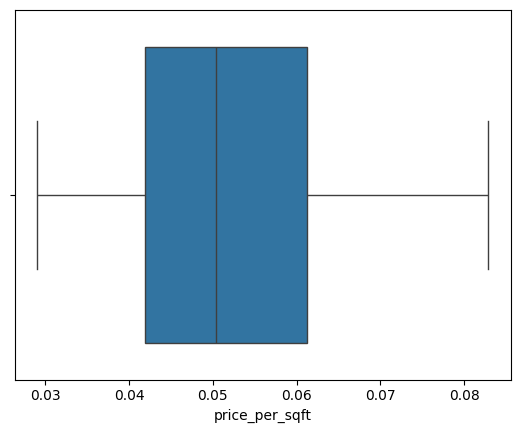

In [20]:
# handling outliers in price_per_sqft
# sns.boxplot(x = 'price_per_sqft', data = df)
# applying IQR method 
q1 = df['price_per_sqft'].quantile(0.25)
q3 = df['price_per_sqft'].quantile(0.75)
IQR = q3-q1
lower = q1 - 0.5*IQR
upper = q3 + 0.5*IQR
df = df[(df['price_per_sqft']>= lower)&(df['price_per_sqft']<= upper)] 
sns.boxplot(x = 'price_per_sqft', data = df)


In [21]:
# remove price_per_sqft 
df = df.drop('price_per_sqft', axis = 1)

In [22]:
df

,location,BHK,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
13310,Rachenahalli,2,1050.0,2.0,52.71
13312,Bellandur,2,1262.0,2.0,47.00
13314,Green Glen Layout,3,1715.0,3.0,112.00
13315,Whitefield,5,3453.0,4.0,231.00


In [23]:
df.reset_index(inplace=True)
df = df.drop("index", axis = 1)
df

,location,BHK,total_sqft,bath,price
0,Electronic City Phase II,2,1056.0,2.0,39.07
1,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Uttarahalli,3,1440.0,2.0,62.00
3,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...
9356,Rachenahalli,2,1050.0,2.0,52.71
9357,Bellandur,2,1262.0,2.0,47.00
9358,Green Glen Layout,3,1715.0,3.0,112.00
9359,Whitefield,5,3453.0,4.0,231.00


In [24]:
df.to_csv('cleaned_data.csv')

## Data visualization 


## Modle training

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [26]:
# encoding
encoder = LabelEncoder()
df['location'] = encoder.fit_transform(df['location'])

In [27]:
# encoder serialization
import pickle
with open("label_encoder.pkl","wb") as file:
    model = pickle.dump(encoder,file)

In [28]:
# divide the dat into input and output
x = df.drop("price", axis=1)
y = df["price"]

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.3, random_state = 42)

In [30]:
model = LinearRegression()
LR = model.fit(x_train, y_train)

In [31]:
ypre = model.predict(x_test)
ypre

array([82.02250319, 62.36595282, 78.92817568, ..., 67.21954379,
       63.22784938, 66.58757742], shape=(2809,))

In [32]:
# underfitting or overfitting using score
print("Training effic: ", model.score(x_train, y_train))
print("Testing effic: ", model.score(x_test, y_test))

Training effic:  0.8729434702335231
Testing effic:  0.8119143581760945


In [33]:
# Model Serialization -> saving the trained model
# req> it skips the contionous training process
# using pickle
import pickle
with open("Linear_model.pkl","wb") as file:
    pickle.dump(LR, file)